In [1]:
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import json

In [2]:
project_root = Path.cwd().parent

raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"

In [3]:
boundary_path = (
    processed_dir / "long_beach_peninsula_boundary.geojson"
)

with open(boundary_path, "r") as f:
    boundary_geojson = json.load(f)

peninsula = gpd.GeoDataFrame.from_features(
    boundary_geojson["features"],
    crs="EPSG:4326"
)

peninsula

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-124.07901 46.29872, -124.07899 46.2...",-124.079009,46.269938,-123.945187,46.662196,323453610,relation,15532796,46.466614,-124.042991,natural,peninsula,22,0.422134,peninsula,Long Beach Peninsula,"Long Beach Peninsula, Ocean Park, Pacific Coun..."


<Axes: >

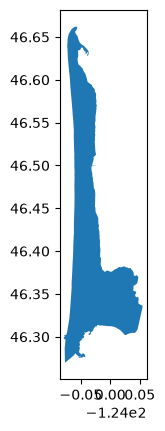

In [4]:
peninsula.plot()

In [5]:
facilities_url = (
    "https://gis.dnr.wa.gov/site3/rest/services/"
    "Geology/Tsunami_Hazard/FeatureServer/26"
)

In [6]:
response = requests.get(
    facilities_url,
    params={"f": "json"}
)

response.raise_for_status()

facilities_metadata = response.json()

print("Layer name:", facilities_metadata["name"])
print("Geometry type:", facilities_metadata["geometryType"])
print("Maximum records:", facilities_metadata["maxRecordCount"])

Layer name: Assembly Areas, Shelters, and Other Facilities
Geometry type: esriGeometryPoint
Maximum records: 2000


In [7]:
facility_fields = pd.DataFrame([
    {
        "name": field["name"],
        "alias": field.get("alias"),
        "type": field["type"]
    }
    for field in facilities_metadata["fields"]
])

facility_fields

,name,alias,type
0,OBJECTID,OBJECTID,esriFieldTypeOID
1,SITE_TYPE,Site Type,esriFieldTypeString
2,SITE_NAME,Site Name,esriFieldTypeString
3,SITE_DESCRIPTION,Site Description,esriFieldTypeString
4,RTU_NO,RTU Number,esriFieldTypeString
5,LATITUDE,Latitude,esriFieldTypeDouble
6,LONGITUDE,Longitude,esriFieldTypeDouble
7,ELEVATION_FT,Elevation (ft),esriFieldTypeInteger
8,GLOBALID,GLOBALID,esriFieldTypeGlobalID


In [8]:
query_url = f"{facilities_url}/query"

params = {
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
    "outSR": 4326,
    "f": "geojson"
}

response = requests.get(query_url, params=params)
response.raise_for_status()

facilities_geojson = response.json()

print("Facilities downloaded:", len(facilities_geojson["features"]))

Facilities downloaded: 155


In [9]:
facilities = gpd.GeoDataFrame.from_features(
    facilities_geojson["features"],
    crs="EPSG:4326"
)

facilities.head()

,geometry,OBJECTID,SITE_TYPE,SITE_NAME,SITE_DESCRIPTION,RTU_NO,LATITUDE,LONGITUDE,ELEVATION_FT,GLOBALID
0,POINT (-122.60784 48.48821),185,Post-tsunami assembly area,St Mary's Catholic Church,4001 St. Mary's Dr,None,48.488213,-122.607840,232,{25AEB404-D2B9-45F3-8825-B052B11BF193}
1,POINT (-122.62162 48.50162),186,Post-tsunami assembly area,Island View Elementary School,2501 J Ave,None,48.501621,-122.621620,128,{9C4B6255-B618-4E31-9B18-1EFD96427996}
2,POINT (-122.65998 48.49851),187,Post-tsunami assembly area,Anacortes Airport,Airport Rd,None,48.498514,-122.659977,249,{F7894F40-BA97-44CA-89BF-C38469EDF3C3}
3,POINT (-122.62251 48.50653),188,Post-tsunami assembly area,Anacortes High School,20th St,None,48.506530,-122.622514,130,{F4697C41-7DC5-402A-877B-ADCC1F909E9D}
4,POINT (-122.49309 48.56958),189,Post-tsunami assembly area,Community of Christ Campground,11633 Scott Rd,None,48.569575,-122.493092,32,{6A80BD35-B923-4588-9CA2-382E6C18E37A}


In [10]:
facilities["SITE_TYPE"].value_counts(dropna=False)

SITE_TYPE
Post-tsunami assembly area    92
Fire Station                  31
Police Station                14
Hospital                       7
Post-tsunami shelter           4
Stair                          4
Clinic                         3
Name: count, dtype: int64

In [11]:
facilities["SITE_TYPE"].unique()

<StringArray>
['Post-tsunami assembly area',       'Post-tsunami shelter',
               'Fire Station',             'Police Station',
                   'Hospital',                      'Stair',
                     'Clinic']
Length: 7, dtype: str

In [12]:
facilities[
    [
        "SITE_TYPE",
        "SITE_NAME",
        "SITE_DESCRIPTION",
        "LATITUDE",
        "LONGITUDE",
        "ELEVATION_FT"
    ]
].head(20)

,SITE_TYPE,SITE_NAME,SITE_DESCRIPTION,LATITUDE,LONGITUDE,ELEVATION_FT
0,Post-tsunami assembly area,St Mary's Catholic Church,4001 St. Mary's Dr,48.488213,-122.607840,232
1,Post-tsunami assembly area,Island View Elementary School,2501 J Ave,48.501621,-122.621620,128
2,Post-tsunami assembly area,Anacortes Airport,Airport Rd,48.498514,-122.659977,249
3,Post-tsunami assembly area,Anacortes High School,20th St,48.506530,-122.622514,130
4,Post-tsunami assembly area,Community of Christ Campground,11633 Scott Rd,48.569575,-122.493092,32
5,Post-tsunami assembly area,Chuckanut Manor Parking Lot,3056 Chuckanut Dr,48.602417,-122.427577,41
6,Post-tsunami assembly area,Bay View Civic Hall,12587 C St,48.485941,-122.474468,69
7,Post-tsunami assembly area,Skagit Regional Airport,15195 Crosswind Dr,48.465334,-122.418024,84
8,Post-tsunami assembly area,Swinomish Casino and Lodge,12911 Casino Dr,48.457445,-122.520376,14
9,Post-tsunami assembly area,Jefferson Elementary School,218 E 12th St,48.108016,-123.439719,211


In [13]:
study_geom = peninsula.geometry.union_all()

In [14]:
long_beach_facilities = facilities[
    facilities.geometry.intersects(study_geom)
].copy()

print("Facilities in Long Beach study area:", len(long_beach_facilities))

Facilities in Long Beach study area: 8


In [15]:
long_beach_facilities[
    [
        "SITE_TYPE",
        "SITE_NAME",
        "SITE_DESCRIPTION",
        "ELEVATION_FT"
    ]
]

,SITE_TYPE,SITE_NAME,SITE_DESCRIPTION,ELEVATION_FT
76,Post-tsunami assembly area,Long Beach Assembly Area,Along 67th Pl-Honeymoon Rd,76
77,Post-tsunami assembly area,Willapa Wildlife Refuge HQ,7112 67th Pl,66
78,Post-tsunami assembly area,School Hill,Along NE Brumback Ave,75
79,Post-tsunami assembly area,North Head Rd #3,Along State Highway 100-Robert Gray Dr,119
80,Post-tsunami assembly area,North Head Rd #2,Along State Highway 100-Robert Gray Dr,109
81,Post-tsunami assembly area,North Head Rd #1,Along State Highway 100-N. Head Rd,93
82,Post-tsunami assembly area,China Hill,"China Hill Ln, Long Beach, WA",39
126,Fire Station,Pacific County Fire Dist. No. 1,26109 Ridge Ave,25


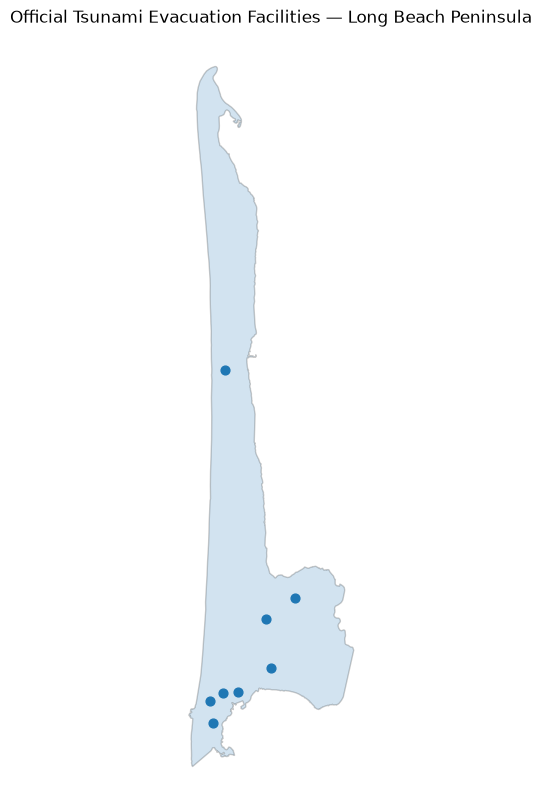

In [16]:
ax = peninsula.plot(
    figsize=(8, 10),
    edgecolor="black",
    alpha=0.2
)

long_beach_facilities.plot(
    ax=ax,
    markersize=40
)

ax.set_title("Official Tsunami Evacuation Facilities — Long Beach Peninsula")
ax.set_axis_off()

In [17]:
assembly_areas = long_beach_facilities[
    long_beach_facilities["SITE_TYPE"] == "Post-tsunami assembly area"
].copy()

print("Official assembly areas:", len(assembly_areas))

assembly_areas[
    [
        "SITE_NAME",
        "SITE_DESCRIPTION",
        "ELEVATION_FT"
    ]
]

Official assembly areas: 7


,SITE_NAME,SITE_DESCRIPTION,ELEVATION_FT
76,Long Beach Assembly Area,Along 67th Pl-Honeymoon Rd,76
77,Willapa Wildlife Refuge HQ,7112 67th Pl,66
78,School Hill,Along NE Brumback Ave,75
79,North Head Rd #3,Along State Highway 100-Robert Gray Dr,119
80,North Head Rd #2,Along State Highway 100-Robert Gray Dr,109
81,North Head Rd #1,Along State Highway 100-N. Head Rd,93
82,China Hill,"China Hill Ln, Long Beach, WA",39


In [18]:
print("Missing names:", assembly_areas["SITE_NAME"].isna().sum())
print("Missing elevations:", assembly_areas["ELEVATION_FT"].isna().sum())
print("Duplicate names:", assembly_areas["SITE_NAME"].duplicated().sum())
print("All geometries valid:", assembly_areas.geometry.is_valid.all())

Missing names: 0
Missing elevations: 0
Duplicate names: 0
All geometries valid: True


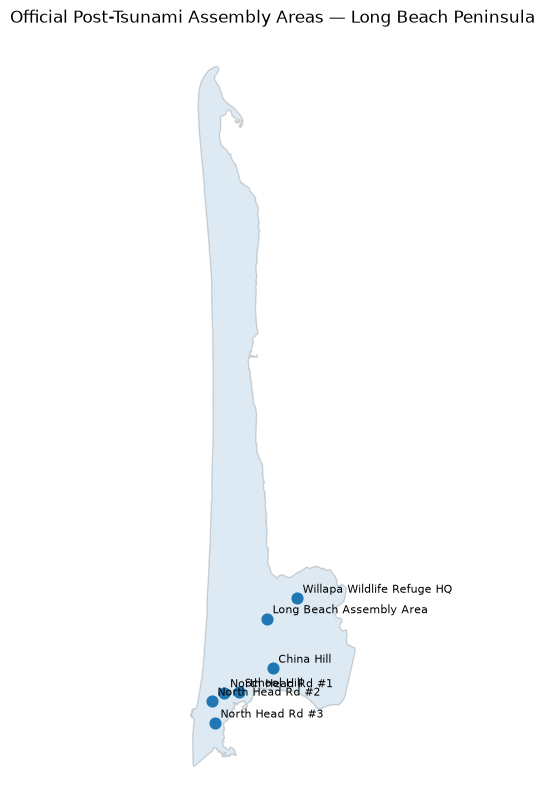

In [19]:
ax = peninsula.plot(
    figsize=(8, 10),
    edgecolor="black",
    alpha=0.15
)

assembly_areas.plot(
    ax=ax,
    markersize=60
)

for _, row in assembly_areas.iterrows():
    ax.annotate(
        row["SITE_NAME"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Official Post-Tsunami Assembly Areas — Long Beach Peninsula")
ax.set_axis_off()

In [20]:
raw_facilities_path = raw_dir / "wgs_tsunami_facilities.geojson"

with open(raw_facilities_path, "w") as f:
    json.dump(facilities_geojson, f)

print(f"Saved raw facilities to: {raw_facilities_path}")

Saved raw facilities to: /Users/zml/Desktop/Projects/tsunami-evacuation-resilience/data/raw/wgs_tsunami_facilities.geojson


In [21]:
assembly_path = (
    processed_dir / "long_beach_assembly_areas.geojson"
)

assembly_path.write_text(
    assembly_areas.to_json(),
    encoding="utf-8"
)

print(f"Saved assembly areas to: {assembly_path}")

Saved assembly areas to: /Users/zml/Desktop/Projects/tsunami-evacuation-resilience/data/processed/long_beach_assembly_areas.geojson


## Vertical Evacuation Structures

In [22]:
vertical_url = (
    "https://gis.dnr.wa.gov/site3/rest/services/"
    "Geology/Tsunami_Hazard/FeatureServer/23"
)

In [23]:
response = requests.get(
    vertical_url,
    params={"f": "json"}
)

response.raise_for_status()

vertical_metadata = response.json()

print("Layer name:", vertical_metadata["name"])
print("Geometry type:", vertical_metadata["geometryType"])
print("Maximum records:", vertical_metadata["maxRecordCount"])

Layer name: Vertical Evacuation Structures (VES)
Geometry type: esriGeometryPoint
Maximum records: 2000


In [24]:
vertical_fields = pd.DataFrame([
    {
        "name": field["name"],
        "alias": field.get("alias"),
        "type": field["type"]
    }
    for field in vertical_metadata["fields"]
])

vertical_fields

,name,alias,type
0,OBJECTID,OBJECTID,esriFieldTypeOID
1,SITE_TYPE,Site Type,esriFieldTypeString
2,SITE_NAME,Site Name,esriFieldTypeString
3,SITE_DESCRIPTION,Site Description,esriFieldTypeString
4,RTU_NO,RTU Number,esriFieldTypeString
5,LATITUDE,Latitude,esriFieldTypeDouble
6,LONGITUDE,Longitude,esriFieldTypeDouble
7,ELEVATION_FT,Elevation (ft),esriFieldTypeInteger
8,GLOBALID,GLOBALID,esriFieldTypeGlobalID


In [25]:
vertical_query_url = f"{vertical_url}/query"

vertical_params = {
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
    "outSR": 4326,
    "f": "geojson"
}

response = requests.get(
    vertical_query_url,
    params=vertical_params
)

response.raise_for_status()

vertical_geojson = response.json()

print(
    "Vertical evacuation features downloaded:",
    len(vertical_geojson["features"])
)

Vertical evacuation features downloaded: 2


In [26]:
vertical = gpd.GeoDataFrame.from_features(
    vertical_geojson["features"],
    crs="EPSG:4326"
)

vertical.head()

,geometry,OBJECTID,SITE_TYPE,SITE_NAME,SITE_DESCRIPTION,RTU_NO,LATITUDE,LONGITUDE,ELEVATION_FT,GLOBALID
0,POINT (-124.10112 46.86389),257,Vertical evacuation structure (VES),Ocosta High School,2450 S Montesano St,None,46.863892,-124.101115,28,{F8EB7F88-F883-475F-9223-F87838EB6247}
1,POINT (-123.99058 46.71015),269,Vertical evacuation structure (VES),Auntie Lee VES,"2844 Fisher Ave, Tokeland, WA 98590",None,46.710151,-123.990582,12,{28E33163-417C-4DBE-BBB4-219752B44654}


In [27]:
vertical["SITE_TYPE"].value_counts(dropna=False)

SITE_TYPE
Vertical evacuation structure (VES)    2
Name: count, dtype: int64

In [28]:
vertical[
    [
        "SITE_TYPE",
        "SITE_NAME",
        "SITE_DESCRIPTION",
        "ELEVATION_FT"
    ]
]

,SITE_TYPE,SITE_NAME,SITE_DESCRIPTION,ELEVATION_FT
0,Vertical evacuation structure (VES),Ocosta High School,2450 S Montesano St,28
1,Vertical evacuation structure (VES),Auntie Lee VES,"2844 Fisher Ave, Tokeland, WA 98590",12


In [29]:
long_beach_vertical = vertical[
    vertical.geometry.intersects(study_geom)
].copy()

print(
    "Vertical evacuation structures in study area:",
    len(long_beach_vertical)
)

Vertical evacuation structures in study area: 0


In [30]:
long_beach_vertical[
    [
        "SITE_TYPE",
        "SITE_NAME",
        "SITE_DESCRIPTION",
        "ELEVATION_FT"
    ]
]

,SITE_TYPE,SITE_NAME,SITE_DESCRIPTION,ELEVATION_FT


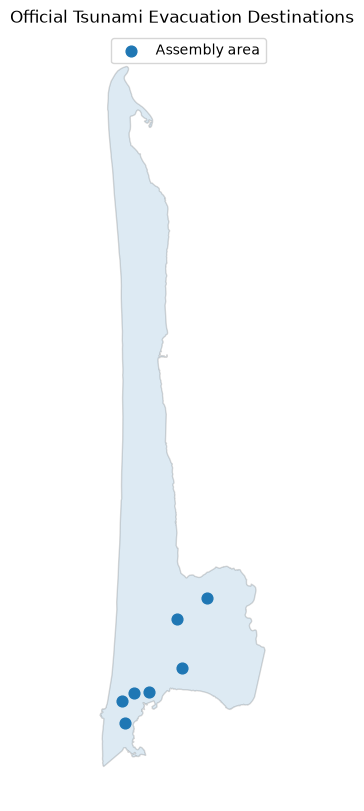

In [31]:
ax = peninsula.plot(
    figsize=(8, 10),
    edgecolor="black",
    alpha=0.15
)

assembly_areas.plot(
    ax=ax,
    markersize=60,
    marker="o",
    label="Assembly area"
)

if len(long_beach_vertical) > 0:
    long_beach_vertical.plot(
        ax=ax,
        markersize=80,
        marker="^",
        label="Vertical evacuation"
    )

ax.set_title("Official Tsunami Evacuation Destinations")
ax.set_axis_off()
ax.legend()

In [32]:
raw_vertical_path = (
    raw_dir / "wgs_vertical_evacuation_structures.geojson"
)

with open(raw_vertical_path, "w") as f:
    json.dump(vertical_geojson, f)

print(f"Saved raw vertical data to: {raw_vertical_path}")

Saved raw vertical data to: /Users/zml/Desktop/Projects/tsunami-evacuation-resilience/data/raw/wgs_vertical_evacuation_structures.geojson


In [33]:
hazard_path = (
    processed_dir / "long_beach_tsunami_hazard.geojson"
)

with open(hazard_path, "r") as f:
    hazard_geojson = json.load(f)

hazard = gpd.GeoDataFrame.from_features(
    hazard_geojson["features"],
    crs="EPSG:4326"
)

hazard.head()

,geometry,OBJECTID,TSUNAMI_SCENARIO_DESCRIPTION,TSUNAMI_SCENARIO_NAME,CITATION,HYPERLINK,Shape__Length,Shape__Area,STUDY_TYPE,GLOBALID
0,"MULTIPOLYGON (((-123.95056 46.2531, -123.92209...",6,Scenario L1; Modeled after a simulated 9.0 mag...,Cascadia subduction zone M9.0,"Allan, J. C.; Zhang, Joseph; O'Brien, F. E.; G...",https://www.oregongeology.org/pubs/sp/SP-51/SP...,2.280569e+06,2.230673e+09,Regional Tsunami Inundation Study,{B365B7F0-403F-4C72-B882-D752F1708404}
1,"MULTIPOLYGON (((-123.85005 46.40154, -123.8501...",2,Scenario L1; Modeled after a simulated 9.0 mag...,Cascadia subduction zone M9.0,"Eungard, D. W.; Forson, Corina; Walsh, T. J.; ...",https://www.dnr.wa.gov/publications/ger_ms2018...,4.876760e+06,2.468984e+10,Regional Tsunami Inundation Study,{C67B6495-3E1C-4675-A2B2-75E0B3F2CDEF}


In [34]:
hazard_geom = hazard.geometry.union_all()

In [35]:
assembly_areas["inside_inundation"] = (
    assembly_areas.geometry.intersects(hazard_geom)
)

assembly_areas[
    [
        "SITE_NAME",
        "ELEVATION_FT",
        "inside_inundation"
    ]
]

,SITE_NAME,ELEVATION_FT,inside_inundation
76,Long Beach Assembly Area,76,False
77,Willapa Wildlife Refuge HQ,66,False
78,School Hill,75,False
79,North Head Rd #3,119,False
80,North Head Rd #2,109,False
81,North Head Rd #1,93,False
82,China Hill,39,False


In [36]:
print(
    "Assembly areas inside modeled inundation:",
    assembly_areas["inside_inundation"].sum()
)

Assembly areas inside modeled inundation: 0


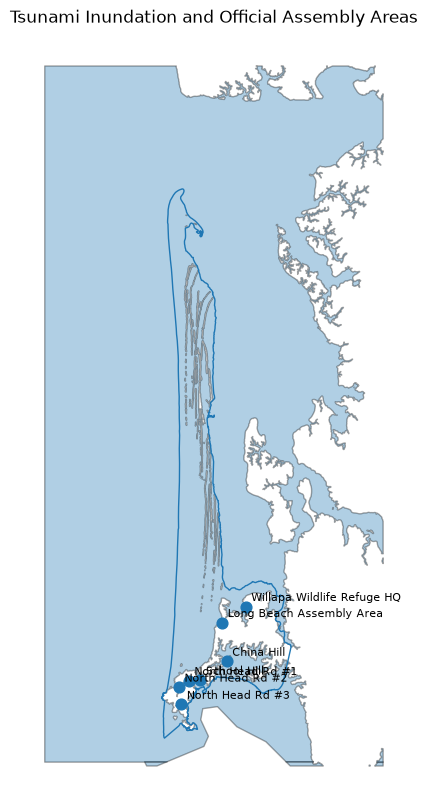

In [37]:
ax = hazard.plot(
    figsize=(8, 10),
    edgecolor="black",
    alpha=0.35
)

peninsula.boundary.plot(
    ax=ax,
    linewidth=1
)

assembly_areas.plot(
    ax=ax,
    markersize=60,
    marker="o"
)

for _, row in assembly_areas.iterrows():
    ax.annotate(
        row["SITE_NAME"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title(
    "Tsunami Inundation and Official Assembly Areas"
)
ax.set_axis_off()

In [38]:
destinations = assembly_areas.copy()

destinations["destination_type"] = "assembly_area"

print("Evacuation destinations:", len(destinations))

Evacuation destinations: 7


In [39]:
destinations_path = (
    processed_dir / "long_beach_evacuation_destinations.geojson"
)

destinations_path.write_text(
    destinations.to_json(),
    encoding="utf-8"
)

print(f"Saved destinations to: {destinations_path}")

Saved destinations to: /Users/zml/Desktop/Projects/tsunami-evacuation-resilience/data/processed/long_beach_evacuation_destinations.geojson
